In [ ]:
import pandas as pd

results = pd.read_csv("seu_resultado.csv")
len(results)

500

In [128]:
results.head()

,#,Texto,Classificação
0,1,never applied credit card never possessed phys...,"{'classification': 'credit card', 'metadata': ..."
1,2,contacted experian several time clearly take b...,"{'classification': 'assistant\n\nassistant', '..."
2,3,legal process collection state record consumer...,"{'classification': 'credit report', 'metadata'..."
3,4,ny social security dob texas equifax informati...,"{'classification': 'credit reporting', 'metada..."
4,5,getting adverse action letter lender problem m...,"{'classification': 'assistant\n\nassistant', '..."


In [129]:
for r in results["Classificação"].to_list():
    if r.startswith("ERRO:"):
        print(r)

In [130]:
classifications = [eval(r) if not r.startswith("ERRO:") else {"classification": "error"} for r in results["Classificação"].to_list()]

In [131]:
classifications[0]["classification"]

'credit card'

In [132]:
predictions = [c["classification"] for c in classifications]
predictions[:5]

['credit card',
 'assistant\n\nassistant',
 'credit report',
 'credit reporting',
 'assistant\n\nassistant']

In [133]:
df_short_500 = pd.read_csv("short-500.csv")
len(df_short_500)

500

In [134]:
df_short_500.head()

,product,narrative
0,debt_collection,paid account settlement told exchange settleme...
1,credit_reporting,received recent credit report hard inquiry pul...
2,retail_banking,deposited suntrust bank account suntrust able ...
3,credit_reporting,day late ask company show proff failed acknowl...
4,credit_reporting,reporting closed account year old violation fa...


In [135]:
df_short_500["product"].to_list()[:5]

['debt_collection',
 'credit_reporting',
 'retail_banking',
 'credit_reporting',
 'credit_reporting']

In [136]:
true_labels = df_short_500["product"].to_list()

In [137]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score, classification_report, matthews_corrcoef

known_labels = sorted(set(true_labels))

def normalize_prediction(pred, labels):
    pred_normalized = pred.lower().replace("_", " ").strip()
    # Tenta correspondência exata primeiro
    for label in labels:
        label_normalized = label.lower().replace("_", " ")
        if pred_normalized == label_normalized:
            return label
    # Depois tenta verificar se o label está contido na predição
    for label in labels:
        label_normalized = label.lower().replace("_", " ")
        if label_normalized in pred_normalized:
            return label
    return pred

predictions_normalized = [normalize_prediction(p, known_labels) for p in predictions]

labels = sorted(set(true_labels) | set(predictions_normalized))
accuracy = accuracy_score(true_labels, predictions_normalized)
precision = precision_score(true_labels, predictions_normalized, average="weighted", zero_division=0)
recall = recall_score(true_labels, predictions_normalized, average="weighted", zero_division=0)
f1 = f1_score(true_labels, predictions_normalized, average="weighted", zero_division=0)
balanced_acc = balanced_accuracy_score(true_labels, predictions_normalized)
mcc = matthews_corrcoef(true_labels, predictions_normalized)
report = classification_report(true_labels, predictions_normalized, zero_division=0)

print(f"Acurácia: {accuracy:.4f}")
print(f"Acurácia balanceada: {balanced_acc:.4f}")
print(f"Precisão ponderada: {precision:.4f}")
print(f"Recall ponderado: {recall:.4f}")
print(f"F1-score ponderado: {f1:.4f}")
print(f"MCC: {mcc:.4f}")

print("\nRelatório de classificação:")
print(report)


Acurácia: 0.1380
Acurácia balanceada: 0.0589
Precisão ponderada: 0.4453
Recall ponderado: 0.1380
F1-score ponderado: 0.2096
MCC: 0.0573

Relatório de classificação:
                                                                                                                                                                                                                                                                                                                                                                           precision    recall  f1-score   support

                                                                                                                                                                                                                                                                                                                                                    account typeauto loan       0.00      0.00      0.00         0
                            

/Users/thauannyramos/projeto 2/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


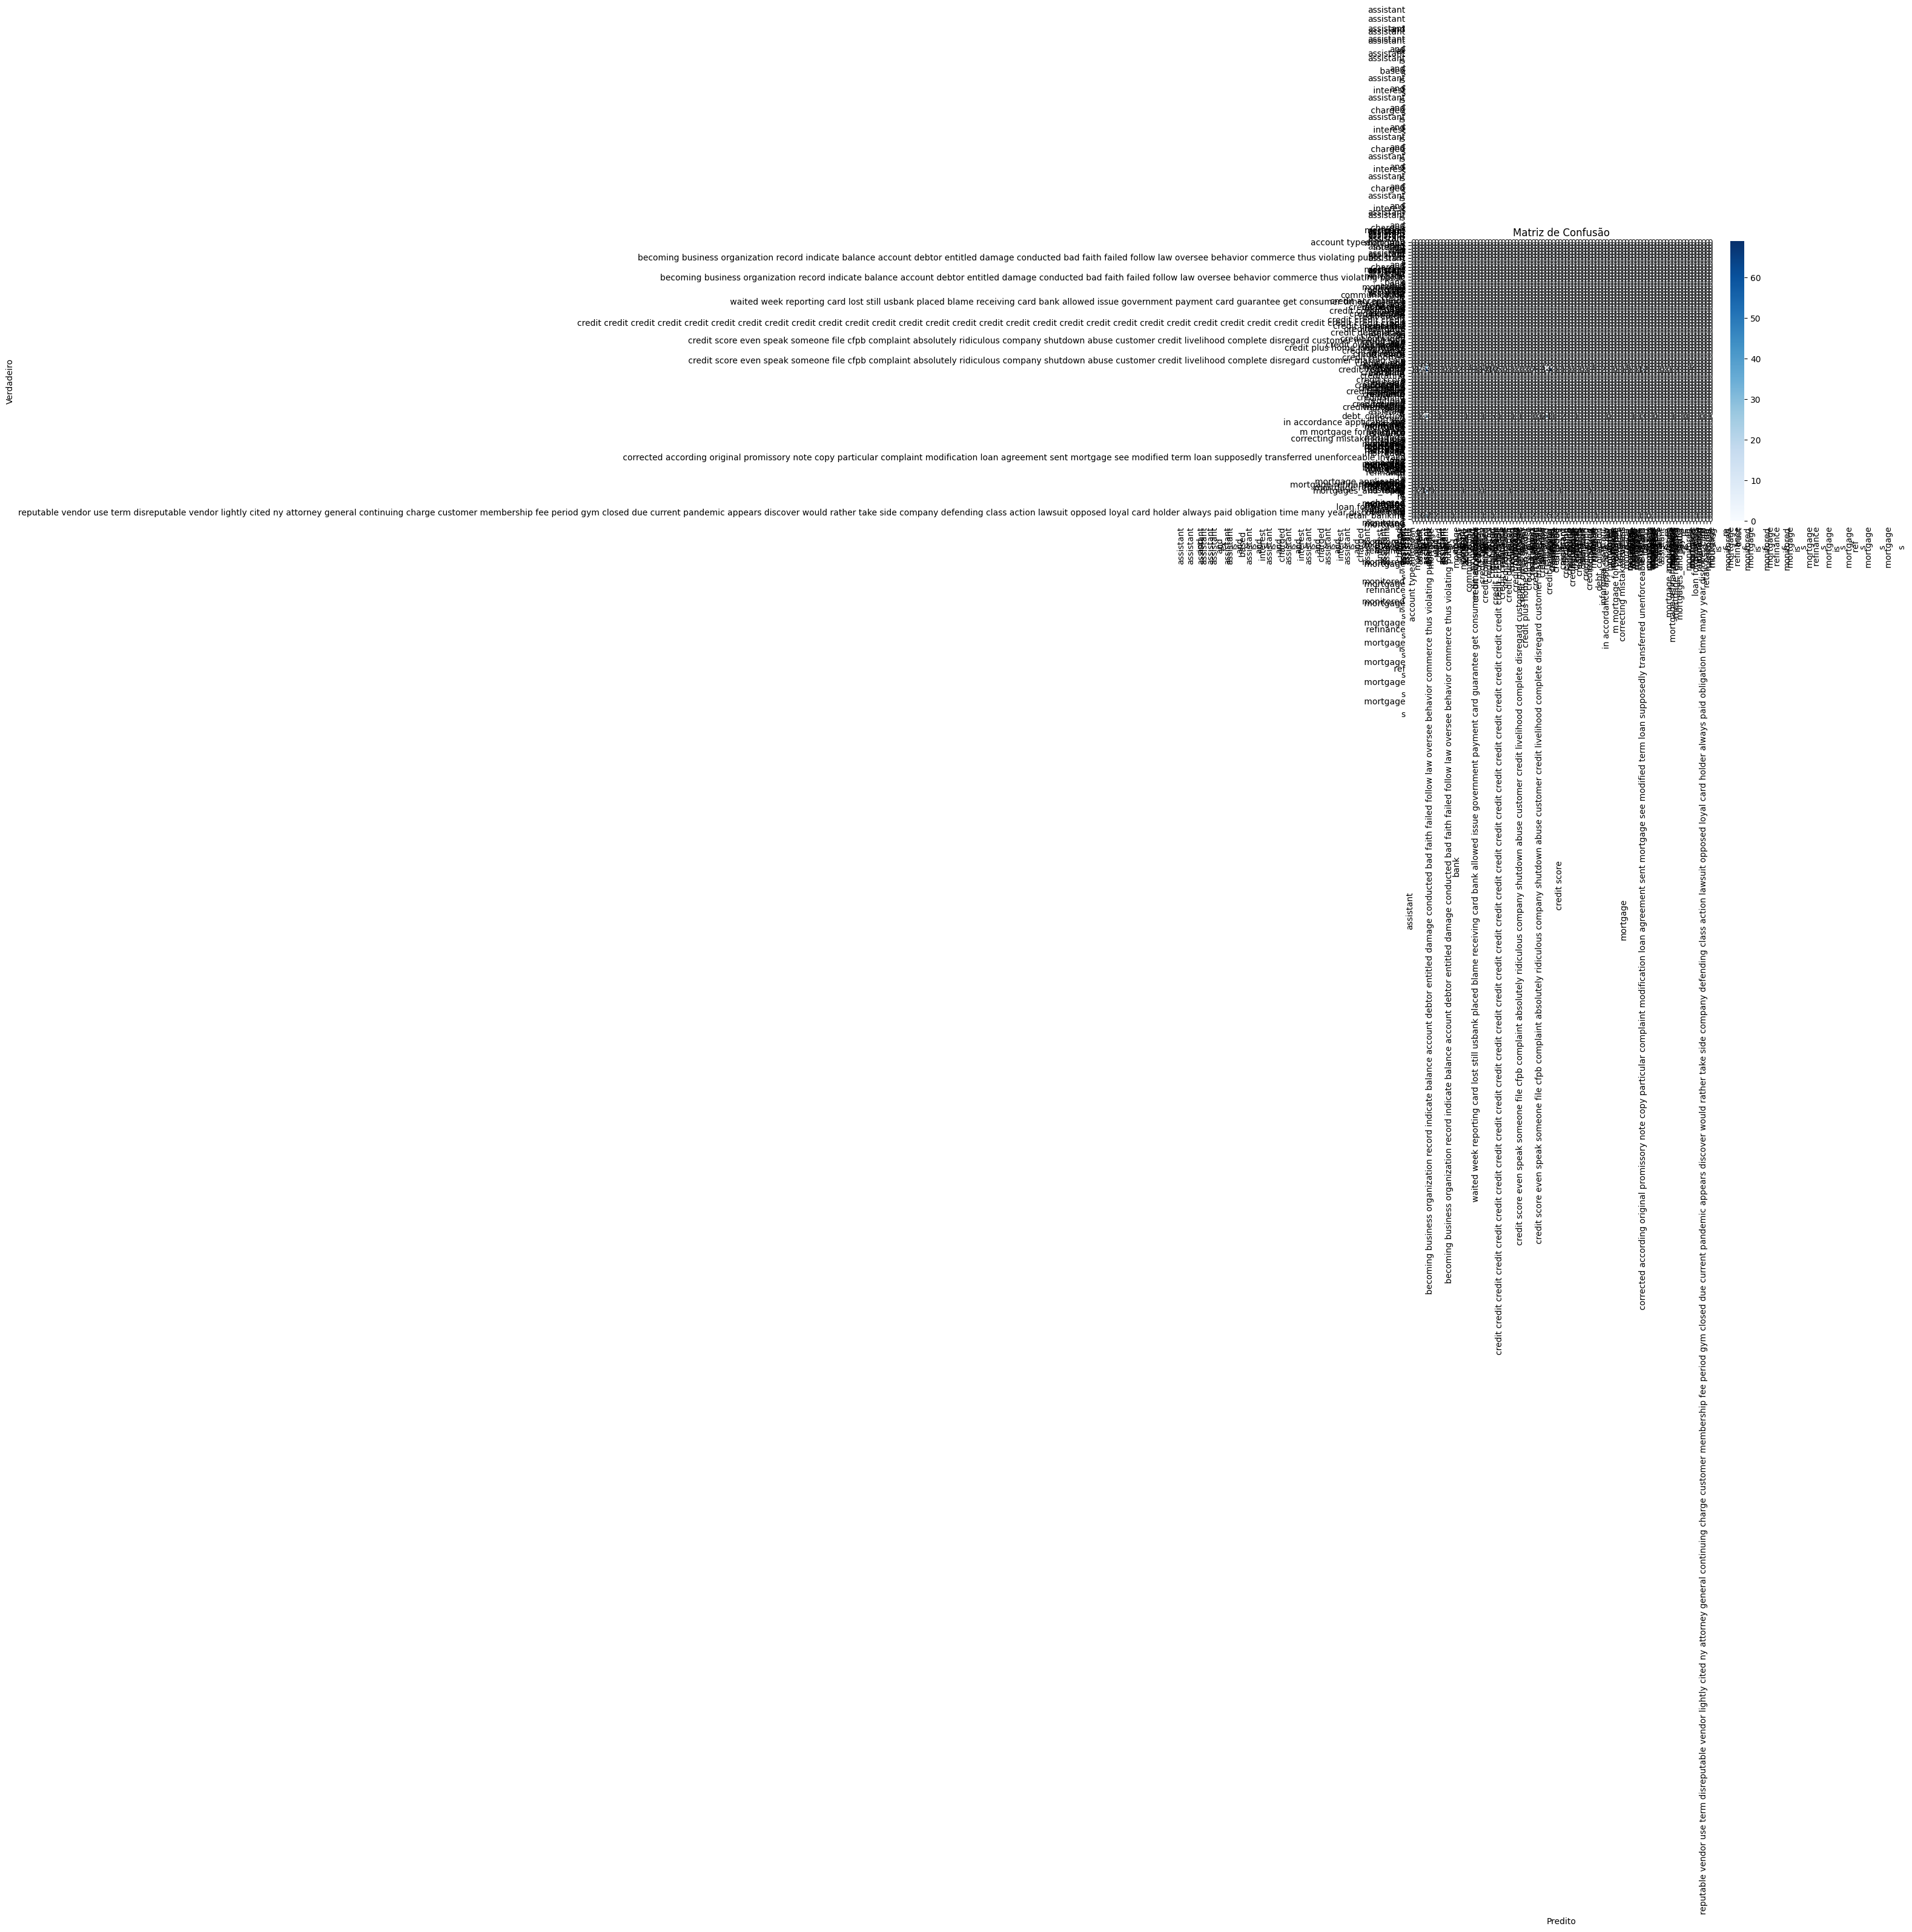

In [138]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, predictions_normalized, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.title('Matriz de Confusão')
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.show()


In [139]:
eval(results["Classificação"][0])["metadata"]

{'model': 'llama3.1:8b-instruct-q8_0',
 'created_at': '2026-05-05T01:26:52.631509Z',
 'done_reason': 'stop',
 'prompt_tokens': 432,
 'completion_tokens': 3,
 'total_tokens': 435,
 'total_duration_s': 1.316,
 'load_duration_s': 0.095,
 'prompt_eval_duration_s': 1.041,
 'eval_duration_s': 0.177,
 'tokens_per_second': 16.9}

In [140]:
total_prompt_tokens = 0
total_completion_tokens = 0
total_tokens = 0
total_queue_time_s = 0
total_prompt_time_s = 0
total_completion_time_s = 0
total_time_s = 0
total_tokens_per_second = 0

for r in results["Classificação"].to_list():
    if not r.startswith("ERRO:"):
        c = eval(r)
        total_prompt_tokens += c["metadata"].get("prompt_tokens") or 0
        total_completion_tokens += c["metadata"].get("completion_tokens") or 0
        total_tokens += c["metadata"].get("total_tokens") or 0
        total_queue_time_s += c["metadata"].get("queue_time_s") or 0
        total_prompt_time_s += c["metadata"].get("prompt_eval_duration_s") or 0
        total_completion_time_s += c["metadata"].get("eval_duration_s") or 0
        total_time_s += c["metadata"].get("total_duration_s") or 0
        total_tokens_per_second += c["metadata"].get("tokens_per_second") or 0


avg_prompt_tokens = total_prompt_tokens / len(results)
avg_completion_tokens = total_completion_tokens / len(results)
avg_tokens = total_tokens / len(results)
avg_queue_time_s = total_queue_time_s / len(results)
avg_prompt_time_s = total_prompt_time_s / len(results)
avg_completion_time_s = total_completion_time_s / len(results)
avg_time_s = total_time_s / len(results)
avg_tokens_per_second = total_tokens_per_second / len(results)


metrics = {
    "total_prompt_tokens": str(total_prompt_tokens).replace('.', ','),
    "average_prompt_tokens": str(avg_prompt_tokens).replace('.', ','),
    "total_completion_tokens": str(total_completion_tokens).replace('.', ','),
    "average_completion_tokens": str(avg_completion_tokens).replace('.', ','),
    "total_tokens": str(total_tokens).replace('.', ','),
    "average_tokens": str(avg_tokens).replace('.', ','),
    "total_queue_time_s": str(total_queue_time_s).replace('.', ','),
    "average_queue_time_s": str(avg_queue_time_s).replace('.', ','),
    "total_prompt_time_s": str(total_prompt_time_s).replace('.', ','),
    "average_prompt_time_s": str(avg_prompt_time_s).replace('.', ','),
    "total_completion_time_s": str(total_completion_time_s).replace('.', ','),
    "average_completion_time_s": str(avg_completion_time_s).replace('.', ','),
    "total_time_s": str(total_time_s).replace('.', ','),
    "average_time_s": str(avg_time_s).replace('.', ','),
    "average_tokens_per_second": str(avg_tokens_per_second).replace('.', ',')
}

df_metrics = pd.DataFrame([metrics])
df_metrics.to_clipboard(index=False)
df_metrics


,total_prompt_tokens,average_prompt_tokens,total_completion_tokens,average_completion_tokens,total_tokens,average_tokens,total_queue_time_s,average_queue_time_s,total_prompt_time_s,average_prompt_time_s,total_completion_time_s,average_completion_time_s,total_time_s,average_time_s,average_tokens_per_second
0,257079,"514,158",10506,"21,012",267585,"535,17",0,"0,0","1261,605999999999","2,5232119999999982","1192,694000000001","2,385388000000002","2501,9740000000006","5,003948000000001","11,296399999999995"
